In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('synthetic_fraud_dataset.csv')
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  str    
 1   User_ID                       50000 non-null  str    
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  str    
 4   Timestamp                     50000 non-null  str    
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  str    
 7   Location                      50000 non-null  str    
 8   Merchant_Category             50000 non-null  str    
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  Failed_Trans

In [5]:
df.columns

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Timestamp', 'Account_Balance', 'Device_Type', 'Location',
       'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity',
       'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d',
       'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age',
       'Transaction_Distance', 'Authentication_Method', 'Risk_Score',
       'Is_Weekend', 'Fraud_Label'],
      dtype='str')

In [6]:
df.describe()

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,99.411012,50294.065981,0.05020,0.098400,7.485240,255.271924,2.003540,119.999940,2499.164155,0.501556,0.299640,0.321340
std,98.687292,28760.458557,0.21836,0.297858,4.039637,141.382279,1.414273,68.985817,1442.013834,0.287774,0.458105,0.466996
min,0.000000,500.480000,0.00000,0.000000,1.000000,10.000000,0.000000,1.000000,0.250000,0.000100,0.000000,0.000000
25%,28.677500,25355.995000,0.00000,0.000000,4.000000,132.087500,1.000000,60.000000,1256.497500,0.254000,0.000000,0.000000
50%,69.660000,50384.430000,0.00000,0.000000,7.000000,256.085000,2.000000,120.000000,2490.785000,0.502250,0.000000,0.000000
75%,138.852500,75115.135000,0.00000,0.000000,11.000000,378.032500,3.000000,180.000000,3746.395000,0.749525,1.000000,1.000000
max,1174.140000,99998.310000,1.00000,1.000000,14.000000,500.000000,4.000000,239.000000,4999.930000,1.000000,1.000000,1.000000


In [7]:
df.isnull().sum()

Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(50000, 21)

<Axes: xlabel='Fraud_Label', ylabel='count'>

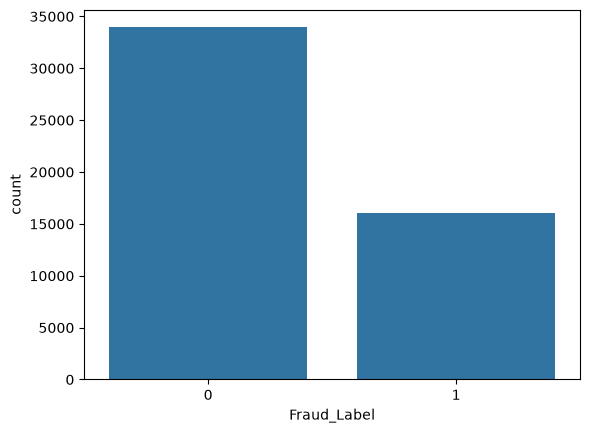

In [10]:
sns.countplot(x = df['Fraud_Label'])

In [11]:
cat_col = df.select_dtypes(include = 'object').columns

In [12]:
cat_col

Index(['Transaction_ID', 'User_ID', 'Transaction_Type', 'Timestamp',
       'Device_Type', 'Location', 'Merchant_Category', 'Card_Type',
       'Authentication_Method'],
      dtype='str')

In [13]:
remove_col = ['Transaction_ID','User_ID','Timestamp']
cat_col = [col for col in cat_col if col not in remove_col]

In [14]:
cat_col

['Transaction_Type',
 'Device_Type',
 'Location',
 'Merchant_Category',
 'Card_Type',
 'Authentication_Method']

In [15]:
df[cat_col].nunique().sort_values()

Device_Type              3
Transaction_Type         4
Authentication_Method    4
Card_Type                4
Merchant_Category        5
Location                 5
dtype: int64

In [16]:
cat_importance = {}

for col in cat_col:
    mean_price = df.groupby(col)["Fraud_Label"].mean()
    cat_importance[col] = mean_price.max() - mean_price.min()

pd.Series(cat_importance).sort_values(ascending=False).head(5)

Merchant_Category        0.009229
Authentication_Method    0.009100
Location                 0.009072
Device_Type              0.006835
Card_Type                0.006823
dtype: float64

In [17]:
top5_cols = pd.Series(cat_importance).sort_values(ascending=False).head(5).index
top5_cols

Index(['Merchant_Category', 'Authentication_Method', 'Location', 'Device_Type',
       'Card_Type'],
      dtype='str')

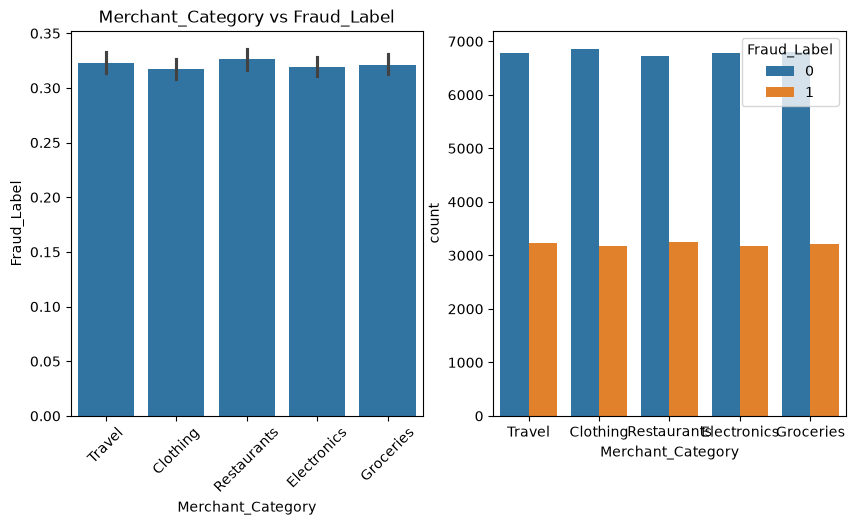

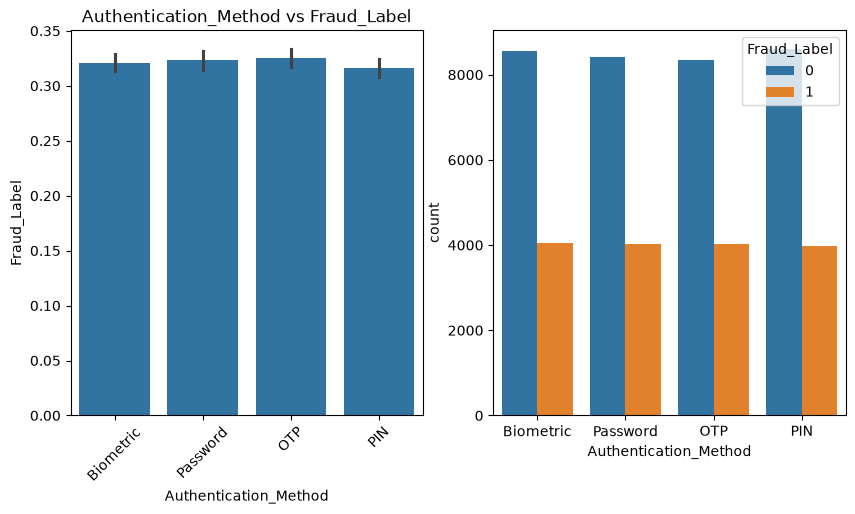

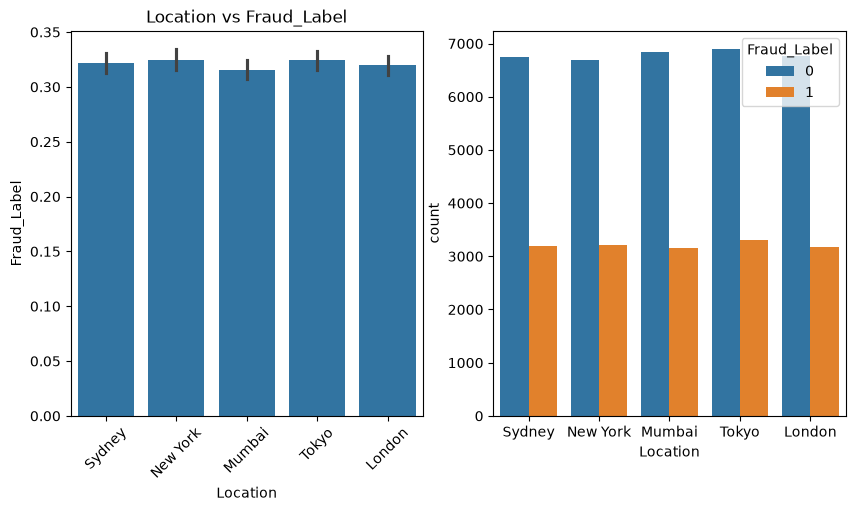

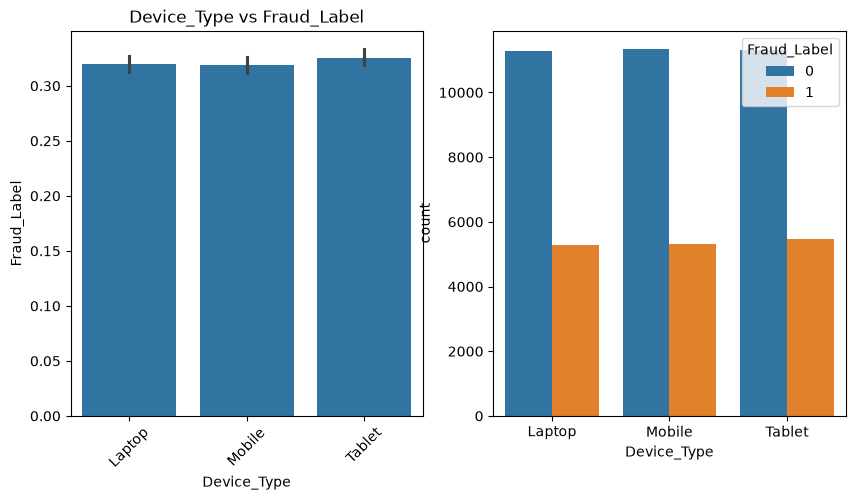

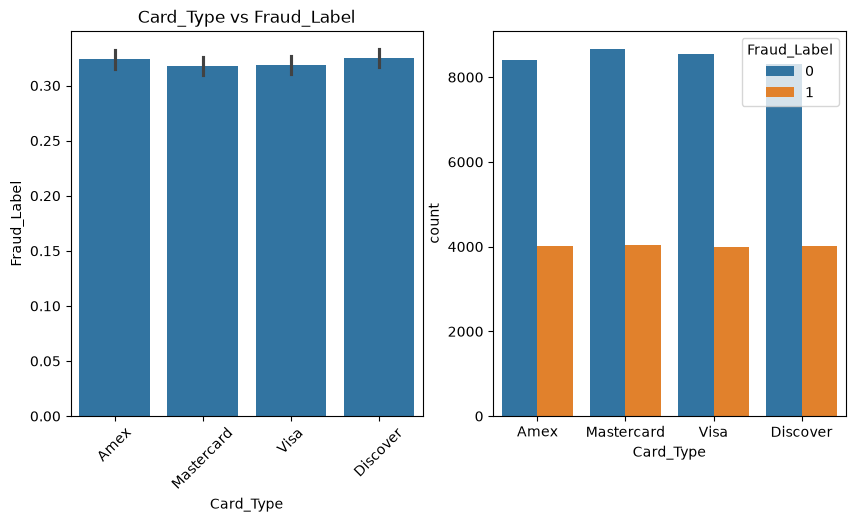

In [18]:
for col in top5_cols:
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    sns.barplot(
        data=df,
        x=col,
        y="Fraud_Label"
    )
    
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Fraud_Label")
    plt.subplot(1,2,2)
    sns.countplot(
        data=df,
        x=col,
        hue="Fraud_Label"
    )
    plt.show()

In [19]:
num_cols = df.select_dtypes(include = ['int64','float64']).columns
num_cols

Index(['Transaction_Amount', 'Account_Balance', 'IP_Address_Flag',
       'Previous_Fraudulent_Activity', 'Daily_Transaction_Count',
       'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age',
       'Transaction_Distance', 'Risk_Score', 'Is_Weekend', 'Fraud_Label'],
      dtype='str')

In [20]:
top5_num = df[num_cols]

num_importance = {}

for col in num_cols:
    if col != "Fraud_Label":
        corr = df[col].corr(df["Fraud_Label"])
        num_importance[col] = abs(corr)

top5_num= (pd.Series(num_importance).sort_values(ascending=False).head(5))
top5_num

Failed_Transaction_Count_7d    0.509871
Risk_Score                     0.385810
Daily_Transaction_Count        0.007065
Account_Balance                0.003153
Card_Age                       0.003120
dtype: float64

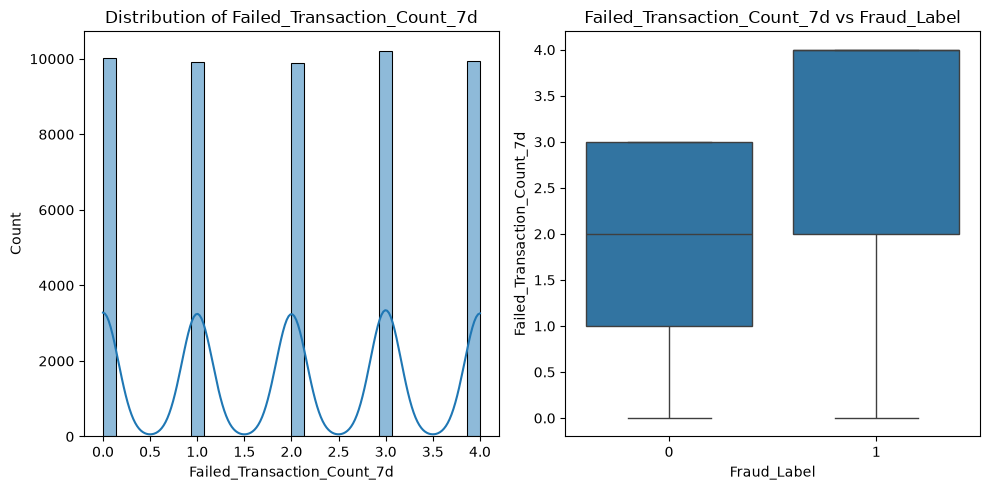

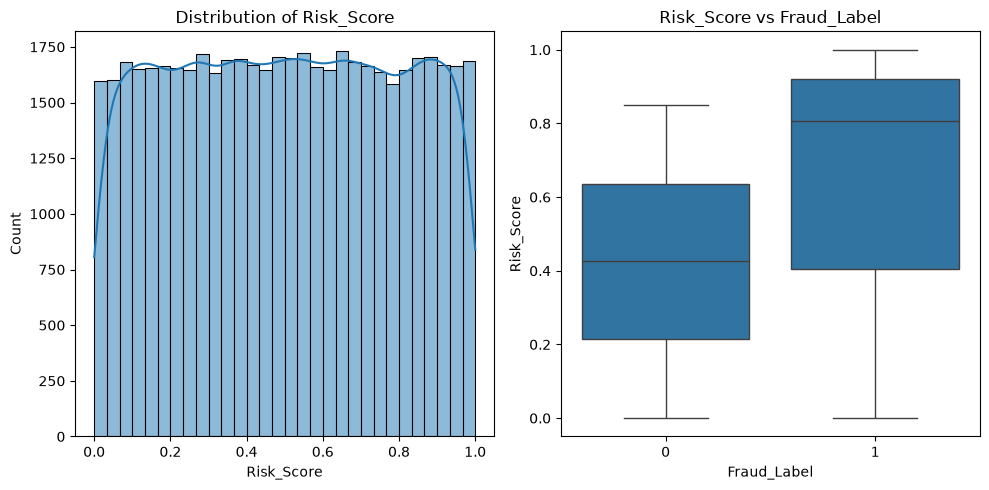

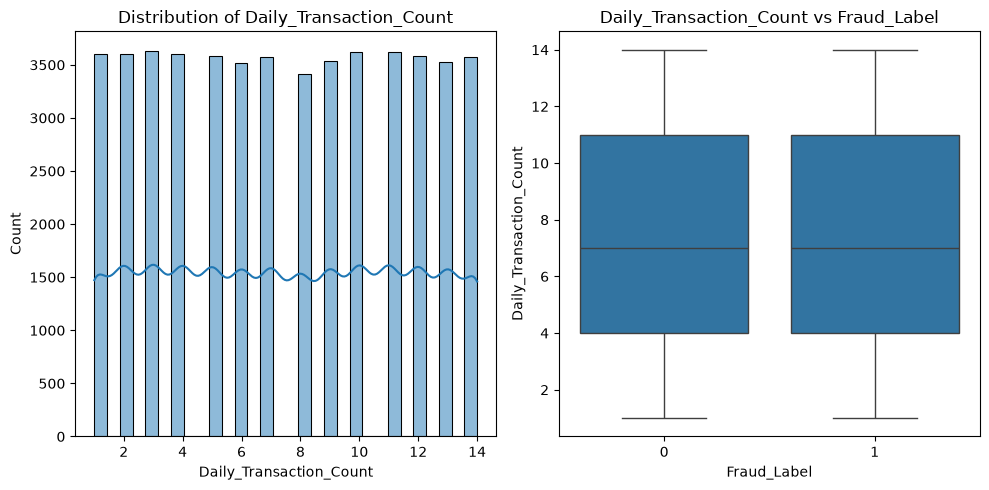

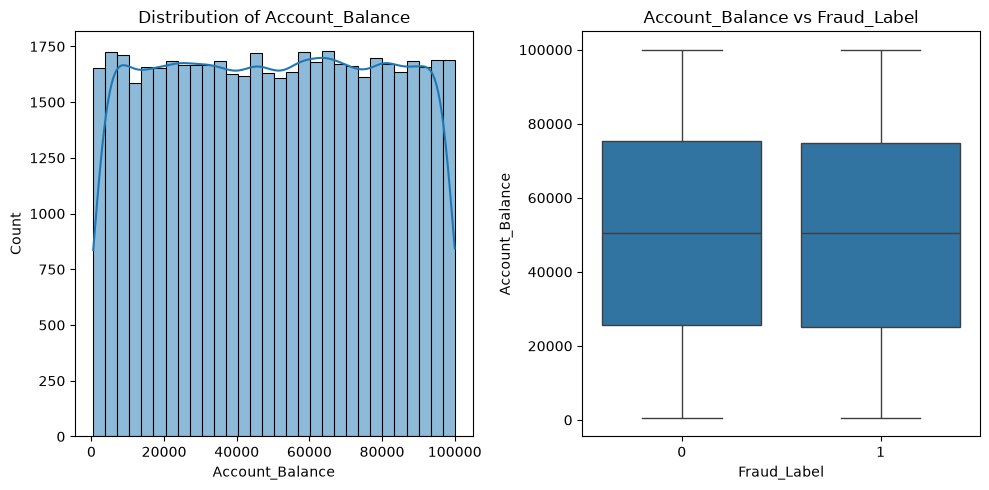

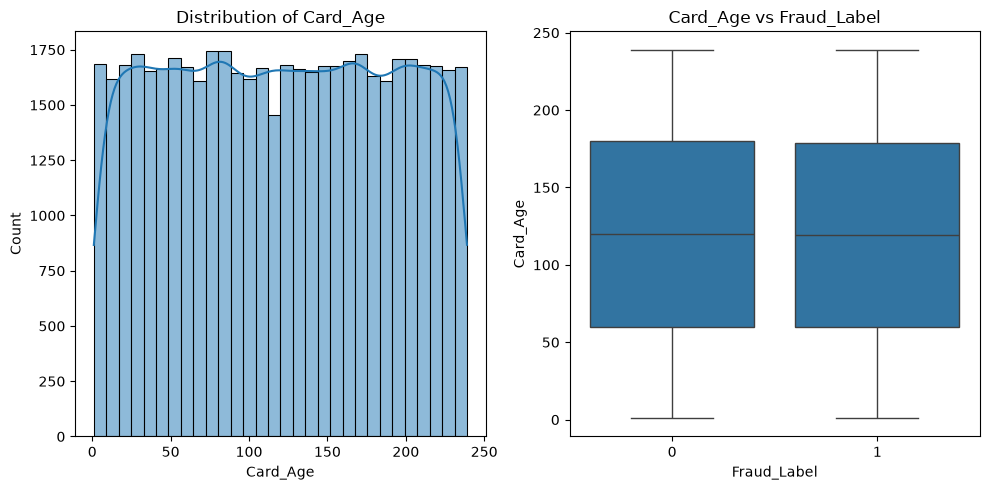

In [24]:
for col in top5_num.index:

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {col}")

    plt.subplot(1,2,2)

    sns.boxplot(
        data=df,
        x="Fraud_Label",
        y=col
    )

    plt.title(f"{col} vs Fraud_Label")

    plt.tight_layout()

    plt.show()

In [62]:
df.corr(numeric_only=True)["Fraud_Label"].sort_values(ascending=False)

Fraud_Label                     1.000000
Failed_Transaction_Count_7d     0.509871
Risk_Score                      0.385810
Hour                            0.005822
Day_of_Week                     0.005272
Day                             0.005262
Is_Weekend                      0.005196
IP_Address_Flag                 0.003028
Transaction_Amount              0.001901
Avg_Transaction_Amount_7d       0.000703
Transaction_Distance           -0.000116
Previous_Fraudulent_Activity   -0.000718
Month                          -0.001213
Card_Age                       -0.003120
Account_Balance                -0.003153
Daily_Transaction_Count        -0.007065
Name: Fraud_Label, dtype: float64

<Axes: >

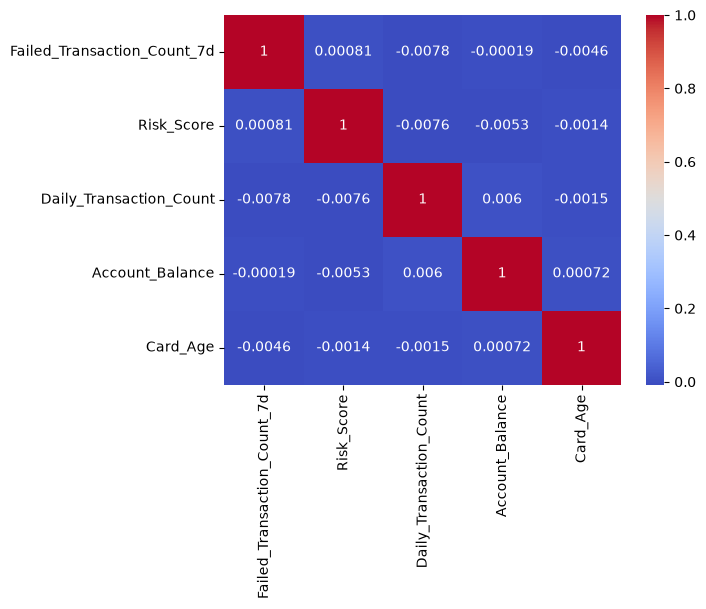

In [26]:
sns.heatmap(df[top5_num.index].corr(), annot=True, cmap='coolwarm')

In [27]:
df['Timestamp'].head()

0    2023-08-14 19:30:00
1    2023-06-07 04:01:00
2    2023-06-20 15:25:00
3    2023-12-07 00:31:00
4    2023-11-11 23:44:00
Name: Timestamp, dtype: str

In [28]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [29]:
df["Hour"] = df["Timestamp"].dt.hour
df["Day"] = df["Timestamp"].dt.day
df["Month"] = df["Timestamp"].dt.month
df["Day_of_Week"] = df["Timestamp"].dt.dayofweek
df["Is_Weekend"] = (df["Day_of_Week"] >= 5).astype(int)

In [30]:
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label,Hour,Day,Month,Day_of_Week
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,65,883.17,Biometric,0.8494,0,0,19,14,8,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,186,2203.36,Password,0.0959,0,1,4,7,6,2
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,226,1909.29,Biometric,0.8400,0,1,15,20,6,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,76,1311.86,OTP,0.7935,0,1,0,7,12,3
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,140,966.98,Password,0.3819,1,1,23,11,11,5


In [63]:
df.groupby("Failed_Transaction_Count_7d")["Fraud_Label"].mean()

Failed_Transaction_Count_7d
0    0.153984
1    0.154350
2    0.145398
3    0.156715
4    1.000000
Name: Fraud_Label, dtype: float64

In [64]:
df["Failed_Transaction_Count_7d"].value_counts()

Failed_Transaction_Count_7d
3    10216
0    10014
4     9954
1     9919
2     9897
Name: count, dtype: int64

In [65]:
pd.crosstab(
    df["Failed_Transaction_Count_7d"],
    df["Fraud_Label"]
)

Fraud_Label,0,1
Failed_Transaction_Count_7d,,
0,8472,1542
1,8388,1531
2,8458,1439
3,8615,1601
4,0,9954


In [66]:
pd.crosstab(
    df["Risk_Score"],
    df["Fraud_Label"]
)

Fraud_Label,0,1
Risk_Score,,
0.0001,5,1
0.0002,4,2
0.0003,4,0
0.0004,2,1
0.0005,3,3
...,...,...
0.9996,0,5
0.9997,0,6
0.9998,0,3


In [32]:
df.drop(columns=["Timestamp","Transaction_ID","User_ID"], inplace=True)

In [33]:
df.head()

,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,...,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label,Hour,Day,Month,Day_of_Week
0,39.79,POS,93213.17,Laptop,Sydney,Travel,0,0,7,437.63,...,65,883.17,Biometric,0.8494,0,0,19,14,8,0
1,1.19,Bank Transfer,75725.25,Mobile,New York,Clothing,0,0,13,478.76,...,186,2203.36,Password,0.0959,0,1,4,7,6,2
2,28.96,Online,1588.96,Tablet,Mumbai,Restaurants,0,0,14,50.01,...,226,1909.29,Biometric,0.8400,0,1,15,20,6,1
3,254.32,ATM Withdrawal,76807.20,Tablet,New York,Clothing,0,0,8,182.48,...,76,1311.86,OTP,0.7935,0,1,0,7,12,3
4,31.28,POS,92354.66,Mobile,Mumbai,Electronics,0,1,14,328.69,...,140,966.98,Password,0.3819,1,1,23,11,11,5


In [42]:
num_cols = [col for col in num_cols if col != "Fraud_Label"]
cat_col = [col for col in cat_col if col != "Fraud_Label"]

In [79]:
x = df.drop(
    columns=[
        "Fraud_Label",
        "Failed_Transaction_Count_7d"
    ]
)
y = df["Fraud_Label"]
num_cols = x.select_dtypes(include=["int64","float64"]).columns

# Update categorical columns
cat_col = x.select_dtypes(include="object").columns

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


In [81]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.33,stratify=y, random_state=42)

In [82]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_col)
    ]
)

In [83]:
pipelinelr = Pipeline(
    steps=[
        ('preprocessor', preprocessor), 
        ('smote', SMOTE(random_state=42)), 
        ('classifier', LogisticRegression(random_state=42))
        ]
    )

In [84]:
pipelinelr.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](20,)","['Transaction_Amount','Transaction_Type','Account_Balance',...,'Day', 'Month','Day_of_Week']"
n_features_in_,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [85]:
y_pred = pipelinelr.predict(x_test)
y_pred

array([0, 1, 1, ..., 0, 0, 0], shape=(16500,))

In [86]:
y_prob = pipelinelr.predict_proba(x_test)[:,1]
y_prob

array([0.16555337, 0.77580675, 0.55486465, ..., 0.48922007, 0.33018998,
       0.18254596], shape=(16500,))

In [88]:
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.80      0.65      0.72     11198
           1       0.47      0.66      0.55      5302

    accuracy                           0.65     16500
   macro avg       0.64      0.66      0.63     16500
weighted avg       0.70      0.65      0.66     16500

Confusion Matrix:
 [[7265 3933]
 [1789 3513]]
ROC AUC Score: 0.7380279350148007


In [89]:
pipelinerf = Pipeline(
    steps=[
        ('preprocessor', preprocessor), 
        ('smote', SMOTE(random_state=42)), 
        ('classifier', RandomForestClassifier(random_state=42))
        ]
    )

In [90]:
pipelinerf.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](20,)","['Transaction_Amount','Transaction_Type','Account_Balance',...,'Day', 'Month','Day_of_Week']"
n_features_in_,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [91]:
y_pred1 = pipelinerf.predict(x_test)
y_pred1

array([0, 1, 0, ..., 0, 0, 0], shape=(16500,))

In [92]:
y_prob1 = pipelinerf.predict_proba(x_test)[:,1]
y_prob1

array([0.35, 0.97, 0.2 , ..., 0.29, 0.21, 0.18], shape=(16500,))

In [93]:
print(classification_report(y_test, y_pred1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob1))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     11198
           1       1.00      0.48      0.65      5302

    accuracy                           0.83     16500
   macro avg       0.90      0.74      0.77     16500
weighted avg       0.86      0.83      0.81     16500

Confusion Matrix:
 [[11189     9]
 [ 2773  2529]]
ROC AUC Score: 0.7419674318088676


In [94]:
pipelinedt = Pipeline(
    steps=[
        ('preprocessor', preprocessor), 
        ('smote', SMOTE(random_state=42)), 
        ('classifier', DecisionTreeClassifier(random_state=42))
        ]
    )

In [95]:
pipelinedt.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](20,)","['Transaction_Amount','Transaction_Type','Account_Balance',...,'Day', 'Month','Day_of_Week']"
n_features_in_,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [96]:
y_pred2 = pipelinedt.predict(x_test)
y_pred2

array([0, 1, 0, ..., 0, 1, 0], shape=(16500,))

In [97]:
y_prob2 = pipelinedt.predict_proba(x_test)[:,1]
y_prob2

array([0., 1., 0., ..., 0., 1., 0.], shape=(16500,))

In [98]:
print(classification_report(y_test, y_pred2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob2))

              precision    recall  f1-score   support

           0       0.80      0.76      0.78     11198
           1       0.55      0.60      0.57      5302

    accuracy                           0.71     16500
   macro avg       0.68      0.68      0.68     16500
weighted avg       0.72      0.71      0.72     16500

Confusion Matrix:
 [[8560 2638]
 [2105 3197]]
ROC AUC Score: 0.6837011128987913


In [99]:
pipelinexgb = Pipeline(
    steps=[
        ('preprocessor', preprocessor), 
        ('smote', SMOTE(random_state=42)), 
        ('classifier', XGBClassifier(random_state=42))
        ]
    )

In [100]:
pipelinexgb.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](20,)","['Transaction_Amount','Transaction_Type','Account_Balance',...,'Day', 'Month','Day_of_Week']"
n_features_in_,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [101]:
y_pred3 = pipelinexgb.predict(x_test)
y_pred3

array([1, 1, 0, ..., 0, 0, 0], shape=(16500,))

In [102]:
y_prob3 = pipelinexgb.predict_proba(x_test)[:,1]
y_prob3

array([0.56550366, 0.9998436 , 0.22476506, ..., 0.24663399, 0.23336367,
       0.09654501], shape=(16500,), dtype=float32)

In [103]:
print(classification_report(y_test, y_pred3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred3))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob3))


              precision    recall  f1-score   support

           0       0.80      0.99      0.89     11198
           1       0.97      0.48      0.64      5302

    accuracy                           0.83     16500
   macro avg       0.89      0.74      0.76     16500
weighted avg       0.86      0.83      0.81     16500

Confusion Matrix:
 [[11123    75]
 [ 2758  2544]]
ROC AUC Score: 0.7330926623813098


In [104]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Store models
models = {
    "Logistic Regression": pipelinelr,
    "Decision Tree": pipelinedt,
    "Random Forest": pipelinerf,
    "XGBoost": pipelinexgb
}

results = []

for name, model in models.items():
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.653212,0.471797,0.662580,0.551145,0.738028
1,Decision Tree,0.712545,0.547901,0.602980,0.574122,0.683701
2,Random Forest,0.831394,0.996454,0.476990,0.645153,0.741967
3,XGBoost,0.828303,0.971363,0.479819,0.642343,0.733093


In [127]:
comparison_df = comparison_df.set_index("Model")

In [128]:
best_model = comparison_df["ROC-AUC"].idxmax()
print("Best Model:", best_model)

Best Model: Random Forest


In [106]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform

In [114]:
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

modelrf = RandomForestClassifier(
    random_state=42
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", modelrf)
    ]
)

In [115]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

classifyrf = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=4,          
    cv=3,              
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1          
)

classifyrf.fit(x_train , y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [5, 10], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",4
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also

In [116]:
y_pred4 = classifyrf.predict(x_test)
y_pred4

array([0, 1, 0, ..., 0, 0, 0], shape=(16500,))

In [117]:
y_prob4 = classifyrf.predict_proba(x_test)[:,1]
y_prob4

array([0.24739507, 0.76746868, 0.24474137, ..., 0.24474486, 0.24215222,
       0.24536373], shape=(16500,))

In [118]:
print(classification_report(y_test, y_pred4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred4))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob4))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     11198
           1       1.00      0.48      0.65      5302

    accuracy                           0.83     16500
   macro avg       0.90      0.74      0.77     16500
weighted avg       0.87      0.83      0.81     16500

Confusion Matrix:
 [[11198     0]
 [ 2776  2526]]
ROC AUC Score: 0.7371248968112738


In [120]:
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

modelrf = RandomForestClassifier(
    random_state=42
)

rft_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", modelrf)
    ]
)

In [121]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10],
    "model__min_samples_leaf": [2, 5],
    "model__min_samples_split": [2, 5]
}

classifyrft = GridSearchCV(
    estimator=rft_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

classifyrft.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10], 'model__min_samples_leaf': [2, 5], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable adde

In [122]:
y_pred5 = classifyrft.predict(x_test)
y_pred5

array([0, 1, 0, ..., 0, 0, 0], shape=(16500,))

In [123]:
y_prob5 = classifyrft.predict_proba(x_test)[:,1]
y_prob5

array([0.24953534, 0.78234703, 0.24429174, ..., 0.24920654, 0.24127658,
       0.24504056], shape=(16500,))

In [124]:
best_rf_gcv = classifyrft.best_estimator_
best_rf_rcv = classifyrf.best_estimator_

In [125]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

tuned_results = [
    {
        "Model": "Random Forest (GridSearchCV)",
        "Accuracy": accuracy_score(y_test, y_pred4),
        "Precision": precision_score(y_test, y_pred4),
        "Recall": recall_score(y_test, y_pred4),
        "F1-Score": f1_score(y_test, y_pred4),
        "ROC-AUC": roc_auc_score(y_test, y_prob4)
    },
    {
        "Model": "Random Forest (RandomizedSearchCV)",
        "Accuracy": accuracy_score(y_test, y_pred5),
        "Precision": precision_score(y_test, y_pred5),
        "Recall": recall_score(y_test, y_pred5),
        "F1-Score": f1_score(y_test, y_pred5),
        "ROC-AUC": roc_auc_score(y_test, y_prob5)
    }
]

In [130]:
comparison_df = pd.concat(
    [
        comparison_df,
        pd.DataFrame(tuned_results).set_index("Model")
    ]
)

comparison_df = comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

In [135]:
comparison_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest,0.831400,0.9965,0.477000,0.645200,0.742000
Random Forest (RandomizedSearchCV),0.831800,1.0000,0.476400,0.645400,0.738200
Logistic Regression,0.653200,0.4718,0.662600,0.551100,0.738000
Random Forest (GridSearchCV),0.831758,1.0000,0.476424,0.645376,0.737125
XGBoost,0.828300,0.9714,0.479800,0.642300,0.733100
Decision Tree,0.712500,0.5479,0.603000,0.574100,0.683700
